# pycorpdiff tutorial

**Comparative corpus analysis for modern Python workflows.**

This notebook is the canonical guided tour. It runs in CI on every push, so if a cell here has stale output, the package is broken — not the notebook.

We'll work with a small synthetic news corpus designed to expose three kinds of contrast:

1. **A frame contrast**: two outlets cover the same topic ('migrant') with engineered semantic fields — one humanising, one criminalising.
2. **A temporal contrast**: discourse shifts around a 2016 policy event — humanising language dominates pre-2016, criminalising language post-2016.
3. **A collocational contrast**: what each frame puts *next to* 'migrant' differs systematically.

All three contrasts are deliberately stark — the point is to see the API at work on data where the signal is unambiguous.

## 1. Imports and version check

In [1]:
import altair as alt
import pandas as pd

import pycorpdiff as pcd

# Emit charts as inline Vega-Lite JSON so they render on GitHub, in
# JupyterLab, VS Code, and nbviewer — anywhere the
# application/vnd.vegalite mime is honoured.
alt.renderers.enable('svg')

print(f'pycorpdiff version: {pcd.__version__}')

pycorpdiff version: 0.1.0a28


## 2. Build the corpus

Two outlets across nineteen years (2005–2023). Each outlet's publication volume shifts around a 2016 policy event: the humanising outlet dominates pre-event coverage (8 articles per year vs 2 from the criminalising outlet), and the ratio inverts post-event.

In [2]:
humanising_templates = [
    'the migrant worker arrived and the migrant family settled here',
    'the migrant community grew and migrant workers thrived together',
    'the migrant family settled and the migrant community welcomed them',
    'the migrant worker and migrant rights advanced in the workplace',
    'the migrant family arrived seeking refuge and dignity',
    'the migrant community organised and the migrant worker spoke out',
    'the migrant family settled and migrant children attended school',
    'the migrant worker contributed and the migrant family flourished',
]
criminalising_templates = [
    'the migrant criminal threat and the migrant invasion grew worse',
    'the migrant threat and the migrant crime increased again',
    'the migrant invasion of migrant criminal gangs spread further',
    'the migrant criminal gangs and migrant invasion stayed dangerous',
    'the migrant threat persisted and the migrant criminal risk grew',
    'the migrant invasion and migrant criminal gangs threatened the border',
    'the migrant criminal element and the migrant threat alarmed residents',
    'the migrant gangs and migrant invasion narrative dominated coverage',
]

EVENT_YEAR = 2016
rows = []
for year in range(2005, 2024):
    humanising_n = 8 if year < EVENT_YEAR else 2
    criminalising_n = 2 if year < EVENT_YEAR else 8
    for i in range(humanising_n):
        rows.append({
            'text': humanising_templates[i % len(humanising_templates)],
            'outlet': 'humanising',
            'date': f'{year}-{(i%12)+1:02d}-15',
            'year': year,
        })
    for i in range(criminalising_n):
        rows.append({
            'text': criminalising_templates[i % len(criminalising_templates)],
            'outlet': 'criminalising',
            'date': f'{year}-{(i%12)+1:02d}-15',
            'year': year,
        })

corpus = pcd.from_dataframe(
    pd.DataFrame(rows),
    text_col='text',
    meta_cols=('outlet', 'date', 'year'),
)
print(f'{len(corpus):,} documents · {corpus.total_tokens():,} tokens')
corpus.docs.head(3)

190 documents · 1,794 tokens


,text,outlet,date,year
0,the migrant worker arrived and the migrant fam...,humanising,2005-01-15,2005
1,the migrant community grew and migrant workers...,humanising,2005-02-15,2005
2,the migrant family settled and the migrant com...,humanising,2005-03-15,2005


## 3. Slice the corpus

Slices remember their filters, so labels propagate into plots and result tables automatically.

In [3]:
humanising = corpus.slice(outlet='humanising')
criminalising = corpus.slice(outlet='criminalising')

print(f'{humanising.label}: {len(humanising)} docs, {humanising.total_tokens()} tokens')
print(f'{criminalising.label}: {len(criminalising)} docs, {criminalising.total_tokens()} tokens')

outlet='humanising': 104 docs, 977 tokens
outlet='criminalising': 86 docs, 817 tokens


## 4. Keyness: which words separate the two frames?

`compare(a, b).keyness()` returns one row per shared-vocabulary term with the signed log-likelihood (Dunning G²), Hardie LogRatio effect size, Gabrielatos %DIFF, BIC-approximated Bayes factor, and Benjamini–Hochberg–adjusted *p*-values. Positive `g2` = overused in A.

In [4]:
keyness = pcd.compare(humanising, criminalising).keyness(min_count=3, dispersion=True)
print(keyness.summary())
keyness.table.head(12)

KeynessResult(log_likelihood, |a|=977, |b|=817, terms=53)


,term,count_a,count_b,expected_a,expected_b,g2,p_value,log_ratio,percent_diff,bayes_factor,dispersion_a,dispersion_b,dispersion_flag,p_adjusted
0,criminal,0,59,32.130992,26.869008,-92.814546,5.743150e-22,-7.152840,-100.0,3.369080e+18,0.000000,0.926357,True,3.043869e-20
1,threat,0,54,29.408027,24.591973,-84.948906,3.061755e-20,-7.026207,-100.0,6.599475e+16,0.000000,0.916211,True,8.113652e-19
2,invasion,0,51,27.774247,23.225753,-80.229523,3.333492e-19,-6.944523,-100.0,6.233160e+15,0.000000,0.909839,True,5.889170e-18
3,family,63,0,34.309365,28.690635,76.572265,2.123004e-18,6.730662,inf,1.001255e+15,0.919790,0.000000,True,2.812980e-17
4,worker,52,0,28.318841,23.681159,63.202505,1.865111e-15,6.456223,inf,1.251233e+12,0.901274,0.000000,True,1.977017e-14
5,gangs,0,32,17.426979,14.573021,-50.340093,1.292811e-12,-6.280390,-100.0,2.015120e+09,0.000000,0.858878,True,1.109200e-11
6,community,41,0,22.328317,18.671683,49.832744,1.674264e-12,6.117017,inf,1.563622e+09,0.877580,0.000000,True,1.109200e-11
7,settled,41,0,22.328317,18.671683,49.832744,1.674264e-12,6.117017,inf,1.563622e+09,0.877629,0.000000,True,1.109200e-11
8,arrived,30,0,16.337793,13.662207,36.462983,1.555932e-09,5.672715,inf,1.954002e+06,0.843929,0.000000,True,9.162713e-09
9,worse,0,19,10.347269,8.652731,-29.889430,4.573996e-08,-5.543425,-100.0,7.302912e+04,0.000000,0.796319,True,1.864783e-07


### 4a. Volcano plot

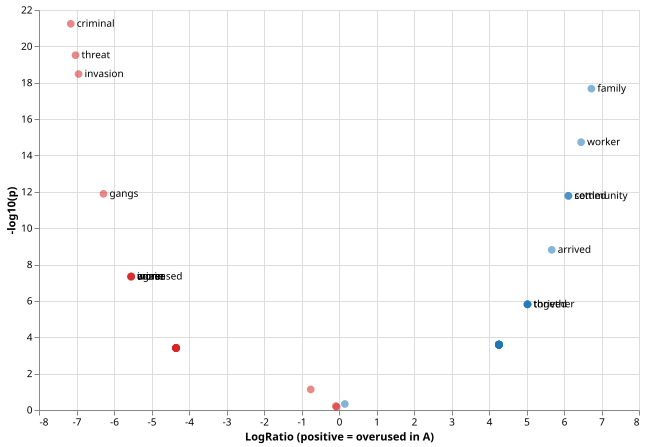

In [5]:
keyness.plot()

### 4b. Top-N bar chart

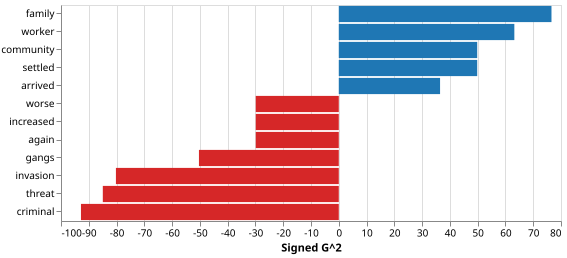

In [6]:
keyness.plot(kind='bar', n=12)

### 4c. Explain a top result

Every Result carries references to its source corpora. `.explain(term)` pulls KWIC contexts from both sides.

In [7]:
keyness.explain('worker', n=3, window=3).table

,corpus,doc_id,position,left,keyword,right
0,outlet='humanising',0,2,the migrant,worker,arrived and the
1,outlet='humanising',3,2,the migrant,worker,and migrant rights
2,outlet='humanising',5,7,and the migrant,worker,spoke out


### 4d. Bootstrap confidence intervals on G²
A G² *point estimate* doesn't say anything about the uncertainty
around it. `ci='bootstrap'` resamples documents with replacement
on each side and adds `g2_ci_lower` and `g2_ci_upper` columns —
the empirical percentile CI. A CI straddling zero signals direction
uncertainty, not just magnitude.

In [8]:
keyness_ci = pcd.compare(humanising, criminalising).keyness(
    min_count=3, ci='bootstrap', n_boot=399, bootstrap_seed=0,
)
keyness_ci.table[['term', 'g2', 'g2_ci_lower', 'g2_ci_upper']].head(8)


,term,g2,g2_ci_lower,g2_ci_upper
0,criminal,-92.814546,-104.413894,-79.514232
1,threat,-84.948906,-98.273717,-72.411024
2,invasion,-80.229523,-94.876165,-65.080938
3,family,76.572265,64.071504,88.508098
4,worker,63.202505,51.247908,74.228643
5,gangs,-50.340093,-62.972366,-36.395236
6,community,49.832744,37.914580,61.069923
7,settled,49.832744,37.973908,61.626477


### 4e. Reference-baseline keyness
Sometimes the relevant comparison isn't to *another corpus* you
have but to a *fixed reference distribution* — the BNC, COCA, an
in-house archive. `pcd.against_baseline(corpus, name)` compares
your corpus to a pre-computed aggregated frequency baseline. The
package ships one starter: 5 Project Gutenberg English-fiction
texts (1813–1897, ~500K tokens). User-built baselines come from
`pcd.baseline_from_corpus(reference_corpus)`.

In [9]:
baseline_result = pcd.against_baseline(corpus, 'gutenberg_fiction', min_count=5)
print(baseline_result.summary())
baseline_result.table[['term', 'count_a', 'count_b', 'g2', 'log_ratio']].head(8)


KeynessResult(log_likelihood, |a|=1,794, |b|=502,234, terms=5,943)


,term,count_a,count_b,g2,log_ratio
0,migrant,369,0,4160.979835,17.658467
1,worker,52,0,586.371142,14.843282
2,invasion,51,0,575.094774,14.815537
3,threat,54,8,561.297607,10.809757
4,criminal,59,26,560.810859,9.295933
5,community,41,3,440.448382,11.696721
6,family,63,217,413.386944,6.352849
7,gangs,32,0,360.843780,14.151404


### 4f. Sub-corpus balancing (CEM)
Two corpora that differ on the variable of interest *also* often
differ on confounders (year, party, length). Naive keyness then
reflects the joint signal. `pcd.match` (Iacus, King & Porro 2012)
coarsens covariates into bins, matches strata across sides, drops
unmatched strata, and reports L1 imbalance before vs after.

In [10]:
matched = pcd.match(humanising, criminalising, on=['year'], seed=0)
print(matched.summary())
matched.imbalance


CEM match on ['year']: 5/5 strata matched, |a|: 104 → 44 (42%), |b|: 86 → 44 (51%). Mean L1 imbalance: 0.517 → 0.000.


,l1_pre,l1_post
covariate,,
year,0.516547,0.0


### 4g. Lexical diversity
How varied is the vocabulary in each corpus? TTR is the naive
measure but is confounded with text length; MATTR, MTLD, and HD-D
correct for that in different ways. `freq=` slices the corpus by
period and returns a per-period trajectory.

In [11]:
ld_h = pcd.lexical_diversity(humanising)
ld_c = pcd.lexical_diversity(criminalising)
print(ld_h.summary())
print(ld_c.summary())

# Temporal: per-year trajectory across the full corpus.
ld_traj = pcd.lexical_diversity(corpus, freq='Y', time_col='date')
ld_traj.table.head(8)


LexicalDiversityResult(label="outlet='humanising'", |tokens|=977, |types|=30, TTR=0.031, MATTR=0.285, MTLD=15.5, HD-D=16.65)
LexicalDiversityResult(label="outlet='criminalising'", |tokens|=817, |types|=27, TTR=0.033, MATTR=0.235, MTLD=13.4, HD-D=15.15)


,period,metric,value,n_tokens,n_types
0,2005,HD-D,20.686111,94,37
1,2006,HD-D,20.686111,94,37
2,2007,HD-D,20.686111,94,37
3,2008,HD-D,20.686111,94,37
4,2009,HD-D,20.686111,94,37
5,2010,HD-D,20.686111,94,37
6,2011,HD-D,20.686111,94,37
7,2012,HD-D,20.686111,94,37


## 5. Collocation shift

What does each outlet put *next to* the word 'migrant'? `collocation_shift` measures the window-based co-occurrence in each corpus and reports `score_a - score_b` for every collocate.

In [12]:
shift = pcd.compare(humanising, criminalising).collocation_shift(
    'migrant', window=3, min_count=3, measure='logDice'
)
print(shift.summary())
shift.table.head(12)

CollocationShiftResult(target='migrant', measure=logDice, window=3, collocates=47)


,collocate,count_a,count_b,score_a,score_b,shift
0,threat,0,92,6.370643,13.704833,-7.334190
1,invasion,0,67,6.370643,13.269461,-6.898817
2,criminal,0,67,6.370643,13.218835,-6.848191
3,family,74,0,13.191263,6.565372,6.625891
4,gangs,0,48,6.370643,12.920433,-6.549789
5,settled,63,0,13.087818,6.565372,6.522446
6,worker,63,0,13.022900,6.565372,6.457529
7,community,60,0,13.017996,6.565372,6.452625
8,arrived,49,0,12.796467,6.565372,6.231095
9,again,0,19,6.370643,11.700440,-5.329796


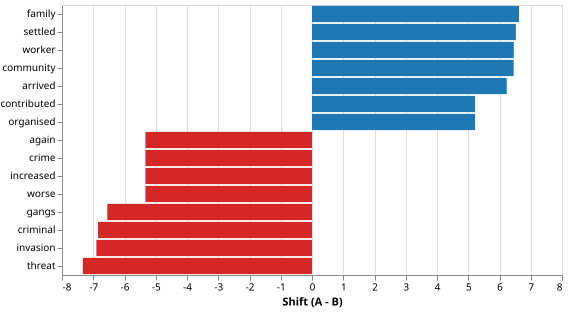

In [13]:
shift.plot(n=15)

### 5a. Explain a collocate

For collocation shifts, `.explain(collocate)` restricts the KWIC lines to windows in which both the target and the collocate appear — direct evidence for what's driving the shift.

In [14]:
shift.explain('criminal', n=3).table

,corpus,doc_id,position,left,keyword,right
0,outlet='criminalising',0,1,the,migrant,criminal threat and
1,outlet='criminalising',2,1,the,migrant,criminal threat and
2,outlet='criminalising',4,1,the,migrant,criminal threat and


## 6. Temporal trajectories

`track(corpus, term).over_time()` returns a tidy frame with per-period relative frequencies and Wilson score confidence intervals. The engineered 2016 publication shift should show up as a step change.

In [15]:
trajectory = pcd.track(corpus, ['worker', 'criminal', 'family']).over_time(
    freq='Y', time_col='date'
)
print(trajectory.summary())
trajectory.table.head(10)

TemporalTrajectory(targets=['worker', 'criminal', 'family'], freq='Y', periods=19)


,period,term,count,total,relfreq,ci_lower,ci_upper
0,2005,criminal,1,94,0.010638,0.00188,0.057823
1,2006,criminal,1,94,0.010638,0.00188,0.057823
2,2007,criminal,1,94,0.010638,0.00188,0.057823
3,2008,criminal,1,94,0.010638,0.00188,0.057823
4,2009,criminal,1,94,0.010638,0.00188,0.057823
5,2010,criminal,1,94,0.010638,0.00188,0.057823
6,2011,criminal,1,94,0.010638,0.00188,0.057823
7,2012,criminal,1,94,0.010638,0.00188,0.057823
8,2013,criminal,1,94,0.010638,0.00188,0.057823
9,2014,criminal,1,94,0.010638,0.00188,0.057823


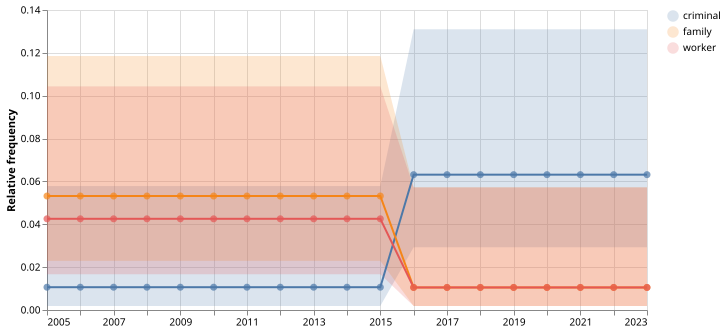

In [16]:
trajectory.plot()

### 6a. Changepoint detection

`TemporalTrajectory.changepoints()` wraps `ruptures` (PELT by default). On our 19-year series with a 4× publication-volume swap, PELT typically lands within ±1 year of the engineered 2016 break — real-world corpora with noise will be similar.

In [17]:
trajectory.changepoints(target='criminal')

,period,index,method
0,2015,10,pelt


### 6c. Burstiness (Kleinberg 1999)
Where `changepoints` says *when did the rate change*, burstiness
says *when was the rate elevated and by how much*. The output is
a per-period intensity state (0 = baseline, 1+ = burst) plus a
per-burst summary table.

In [18]:
bursts = trajectory.burstiness(target='criminal', s=2.0, gamma=1.0)
print(bursts.summary())
bursts.bursts


BurstinessResult(target='criminal', 1 burst(s), max intensity = state 1, base rate p_0 = 3.29e-02)


,start,end,n_periods,max_state,total_count,mean_relfreq
0,2016,2023,8,1,48,0.063158


### 6b. Interrupted time series

If you *know* the event date, segmented regression gives you a level-change and slope-change estimate with confidence intervals. Requires the `[temporal]` extra (statsmodels).

> **Caveat on the synthetic demo.** The bundled Hansard-style sample is deterministic — the engineered relative frequencies for `"criminal"` in the pre-event window have zero variance, so the OLS standard errors below are at floating-point precision and the *p*-values are astronomically small. On real data with realistic noise these numbers will be normal-looking. Treat the ITS output here as a syntactic demonstration of the API, not a statistical worked example.

In [19]:
trajectory.interrupted_time_series(event_date='2016', target='criminal')

,term,coef,std_err,t,p_value,ci_lower,ci_upper
0,intercept,1.063830e-02,6.265560e-18,1.697901e+15,4.771575e-221,1.063830e-02,1.063830e-02
1,time,-7.179285e-19,1.059073e-18,-6.778839e-01,5.081678e-01,-2.975289e-18,1.539432e-18
2,level_change,5.251960e-02,1.014906e-17,5.174821e+15,2.623708e-228,5.251960e-02,5.251960e-02
3,slope_change,4.770490e-18,2.014758e-18,2.367772e+00,3.176059e-02,4.761335e-19,9.064846e-18


## 7. Before/after analysis

`compare.before_after(corpus, event_date=...)` splits the corpus chronologically and returns a regular `Comparison` you can keyness or collocation-shift just like the outlet comparison.

In [20]:
ba = pcd.compare.before_after(corpus, event_date='2016-01-01', time_col='date').keyness(
    min_count=5
)
print(ba.summary())
ba.table.head(8)

KeynessResult(log_likelihood, |a|=1,034, |b|=760, terms=53)


,term,count_a,count_b,expected_a,expected_b,g2,p_value,log_ratio,percent_diff,bayes_factor,p_adjusted
0,gangs,0,32,18.443701,13.556299,-54.968615,1.224699e-13,-6.466533,-100.000000,2.038787e+10,6.490907e-12
1,criminal,11,48,34.005574,24.994426,-37.814783,7.779006e-10,-2.520516,-83.156028,3.841179e+06,2.061437e-08
2,invasion,11,40,29.394649,21.605351,-27.650892,1.453050e-07,-2.260453,-79.787234,2.384535e+04,2.567055e-06
3,family,55,8,36.311037,26.688963,26.396322,2.780695e-07,2.262788,405.319149,1.273436e+04,3.684421e-06
4,worker,44,8,29.971014,22.028986,17.581702,2.752238e-05,1.944106,304.255319,1.552054e+02,2.917372e-04
5,of,0,8,4.610925,3.389075,-13.742154,2.096949e-04,-4.531628,-100.000000,2.275933e+01,5.556915e-04
6,persisted,0,8,4.610925,3.389075,-13.742154,2.096949e-04,-4.531628,-100.000000,2.275933e+01,5.556915e-04
7,further,0,8,4.610925,3.389075,-13.742154,2.096949e-04,-4.531628,-100.000000,2.275933e+01,5.556915e-04


## 8. Semantic shift via embeddings

`compare(a, b).semantic_shift(target, embedder)` encodes every KWIC window around the target in each corpus, averages into a corpus-specific centroid, and reports cosine distance between the centroids. With a real sentence-transformers model (the `[semantic]` extra), this captures meaning shifts that pure frequency analysis misses.

For this tutorial we use the deterministic `HashEmbedder` so the output is reproducible without paying the sentence-transformers download cost. The numbers are not semantically meaningful — they show the *plumbing* working.

In [21]:
sem = pcd.compare(humanising, criminalising).semantic_shift(
    target='migrant',
    embedder=pcd.HashEmbedder(dim=64),
    window=3,
)
sem.table

,target,cosine_similarity,cosine_distance,n_contexts_a,n_contexts_b
0,migrant,0.156336,0.843664,197,172


### 8a. Neighbourhood drift

`neighborhood_drift(a, b, target)` returns the top-k contextual neighbours of the target in each corpus and partitions them into `shared` / `gained_in_a` / `lost_in_a`. Real-world use case: with SBERT, this surfaces words that have *become* semantically close to the target in one corpus but not the other.

In [22]:
drift = pcd.neighborhood_drift(
    humanising,
    criminalising,
    target='migrant',
    k=8,
    embedder=pcd.HashEmbedder(dim=64),
    window=3,
    min_count=2,
)
drift.head(10)

,neighbor,sim_a,sim_b,rank_a,rank_b,drift,status
0,the,0.312826,-0.032431,1.0,NaN,0.345257,gained_in_a
1,and,-0.017790,0.267199,NaN,1.0,-0.284989,lost_in_a
2,contributed,0.196667,NaN,2.0,NaN,0.196667,gained_in_a
3,increased,NaN,0.180785,NaN,2.0,-0.180785,lost_in_a
4,grew,-0.011536,0.131430,NaN,3.0,-0.142966,lost_in_a
5,attended,0.140480,NaN,3.0,NaN,0.140480,gained_in_a
6,persisted,NaN,0.120326,NaN,4.0,-0.120326,lost_in_a
7,element,NaN,0.100437,NaN,5.0,-0.100437,lost_in_a
8,again,NaN,0.099403,NaN,6.0,-0.099403,lost_in_a
9,dominated,NaN,0.083522,NaN,7.0,-0.083522,lost_in_a


### 8b. Word-sense induction + classifier audit

`induce_senses(items, embeddings, ...)` clusters **bring-your-own** embeddings into senses, then lets you audit a hand-built (regex / keyword) sense classifier against the unsupervised partition. The motivating use case: defend a polysemy finding by showing that an independent method recovers the same senses your hand-built buckets do — and locate the records where they disagree.

As in §8 we use the deterministic `HashEmbedder` on a tiny three-sense illustrative corpus (the three senses of "CBD" in the literature: cannabidiol, common **b**ile **d**uct, cortico**b**asal **d**egeneration) so the example is reproducible offline. With real SBERT embeddings the exact same calls run on your corpus — just swap the embedder.

In [23]:
import pandas as pd

# A tiny illustrative three-sense corpus. Each row is a "document"; the
# regex_label is a stand-in for a hand-built keyword classifier.
_senses = {
    "cannabidiol": "cannabidiol cannabinoid receptor epilepsy seizure",
    "biliary":     "common bile duct biliary cholangiography obstruction",
    "neurology":   "corticobasal degeneration parkinsonism cortical atrophy",
}
docs = pd.DataFrame(
    [{"text": stem, "regex_label": ref, "year": f"20{10 + i % 10}"}
     for ref, stem in _senses.items() for i in range(20)]
)

# BYO embeddings: any (n_items, d) matrix. Swap HashEmbedder for
# pcd.SBERTEmbedder() (the [semantic] extra) for meaning-aware vectors.
X = pcd.HashEmbedder(dim=24).encode(docs["text"].tolist())

senses = pcd.induce_senses(docs, X, k=None, k_range=(2, 6), time_col="year")
print(senses.summary())

# Does the unsupervised partition agree with the regex buckets?
print(senses.agreement_with(docs["regex_label"]).summary())

# Plant a mislabelled record, then locate it deterministically
# (the targeted counterpart to a random spot-check):
ref = docs["regex_label"].to_numpy().copy()
ref[0] = "biliary"   # a cannabidiol doc wrongly tagged biliary
senses.leakage_audit(ref, k=3)

3 senses induced over 60 documents (kmeans, silhouette=1.000); largest sense 33.3%
ARI=1.000  V-measure=1.000  (homogeneity=1.000, completeness=1.000)


,doc_id,reference_sense,nearest_other_sense,margin,text
0,0,biliary,cannabidiol,1.283536,cannabidiol cannabinoid receptor epilepsy seizure


## 9. Where to go from here

Beyond this tutorial:

- **Real embeddings**: swap `HashEmbedder` for `pcd.SBERTEmbedder()` (requires `pip install 'pycorpdiff[semantic]'`) to get meaning-aware semantic shifts. The `model_name=` parameter selects the underlying sentence-transformers model — pick a multilingual one for non-English corpora.
- **Multilingual corpora**: plug spaCy / Stanza / jieba into `Corpus(tokenizer=...)`. Any callable mapping `str → list[str]` satisfies the `Tokenizer` protocol.
- **Large corpora**: polars DataFrames slot in via pcd.from_dataframe(polars_df, ...) and corpus.to_polars() round-trips back (pip install "pycorpdiff[polars]"). For now, build the corpus DataFrame in pandas; the analytical layer is vectorised and handles medium-millions of tokens.

Read the [README](../README.md) for the design philosophy and the [CHANGELOG](../CHANGELOG.md) for the latest changes.